# Vector Embeddings

## What is an embedding?

An **embedding** is a list of numbers (a *vector*) that represents the **meaning** of a piece of text. Texts with similar meaning get vectors that sit close together, even when they use completely different words.

```
"How do I reset my password?"    →  [ 0.12, -0.48,  0.91, ...,  0.05]
"I forgot my login credentials"  →  [ 0.10, -0.45,  0.88, ...,  0.07]   ← close: similar meaning
"Easy pizza recipes"             →  [-0.73,  0.22, -0.10, ...,  0.64]   ← far: unrelated topic
```

*(Values are illustrative. Real embeddings have hundreds or thousands of numbers.)*

This is what lets a RAG system find relevant chunks by **meaning** rather than by exact keyword match.

## How it works

```
text ──► tokenizer ──► embedding model (neural network) ──► one fixed-size vector
```

1. **Tokenize**: the text is split into tokens (words or word pieces).
2. **Encode**: a neural network reads the tokens *in context* and turns each one into a vector.
3. **Pool**: those token vectors are combined into a single vector for the whole text.
4. **Output**: the vector always has the same length (the model's *dimension*), whether the input is one word or a full paragraph.

During training the model sees huge numbers of related and unrelated text pairs. It learns to pull related texts close together and push unrelated ones apart, so **distance in the vector space ends up reflecting difference in meaning**.

## Measuring similarity

The most common measure is **cosine similarity**, which compares the *direction* of two vectors:

$$\text{cosine}(A, B) = \frac{A \cdot B}{\|A\|\,\|B\|}$$

| Score | Meaning |
|---|---|
| close to **1** | very similar meaning |
| around **0** | unrelated |
| close to **-1** | opposite direction (rare for text) |

## Where embeddings fit in RAG

1. **Indexing**: every document chunk is embedded and stored in a vector store.
2. **Querying**: the user's question is embedded with the **same model**.
3. **Retrieval**: the vector store returns the chunks whose vectors are closest to the question's vector.
4. **Generation**: those chunks are passed to the LLM as context for the answer.

> **Always use the same embedding model for documents and queries.** Vectors from different models live in different spaces and can't be compared.

## Common embedding models

| Model | Dimensions | Runs |
|---|---|---|
| OpenAI `text-embedding-3-small` | 1536 | API (paid) |
| OpenAI `text-embedding-3-large` | 3072 | API (paid) |
| `sentence-transformers/all-MiniLM-L6-v2` | 384 | Locally (free) |

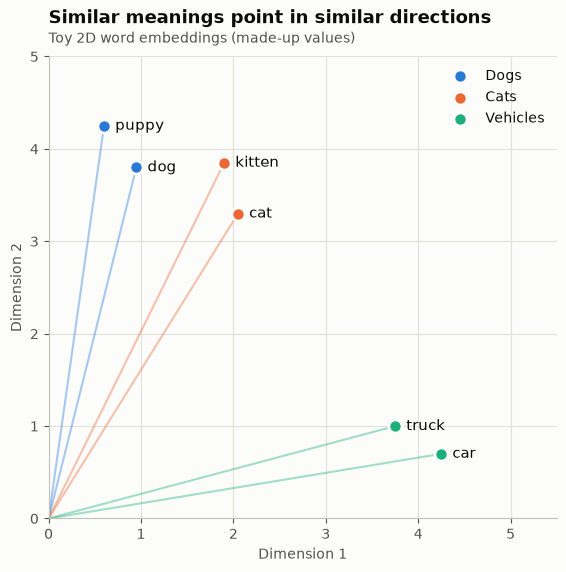

Cosine similarity (1 = same direction, 0 = unrelated)

   dog ↔ puppy   0.995
   cat ↔ kitten  0.995
   car ↔ truck   0.995
   dog ↔ cat     0.952
   dog ↔ car     0.397


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Toy 2D word embeddings (made-up values for illustration).
# Real models use hundreds of dimensions, but the idea is the same:
# words with similar meaning get vectors that point in similar directions.
word_vectors = {
    "puppy":  np.array([0.6, 4.25]),
    "dog":    np.array([0.95, 3.8]),
    "kitten": np.array([1.9, 3.85]),
    "cat":    np.array([2.05, 3.3]),
    "truck":  np.array([3.75, 1.0]),
    "car":    np.array([4.25, 0.7]),
}

groups = {
    "Dogs":     (["dog", "puppy"], "#2a78d6"),
    "Cats":     (["cat", "kitten"], "#eb6834"),
    "Vehicles": (["car", "truck"], "#1baf7a"),
}

fig, ax = plt.subplots(figsize=(7, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

for group, (words, color) in groups.items():
    for i, word in enumerate(words):
        x, y = word_vectors[word]
        ax.plot([0, x], [0, y], color=color, linewidth=1.5, alpha=0.4)  # the vector, drawn from the origin
        ax.scatter(x, y, s=90, color=color, edgecolor="#fcfcfb", linewidth=2, zorder=3,
                   label=group if i == 0 else None)
        ax.annotate(word, (x, y), xytext=(8, 0), textcoords="offset points",
                    va="center", fontsize=11, color="#0b0b0b")

ax.set_title("Similar meanings point in similar directions", loc="left",
             fontsize=13, fontweight="bold", color="#0b0b0b", pad=24)
ax.text(0, 1.03, "Toy 2D word embeddings (made-up values)", transform=ax.transAxes,
        fontsize=10, color="#52514e")

ax.set_xlim(0, 5.5)
ax.set_ylim(0, 5)
ax.set_aspect("equal")  # keep angles true, since cosine similarity is about angle
ax.set_xlabel("Dimension 1", color="#52514e")
ax.set_ylabel("Dimension 2", color="#52514e")
ax.grid(color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="#52514e")
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_color("#c3c2b7")
ax.legend(frameon=False, loc="upper right", labelcolor="#0b0b0b")

plt.show()


def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


pairs = [("dog", "puppy"), ("cat", "kitten"), ("car", "truck"),
         ("dog", "cat"), ("dog", "car")]

print("Cosine similarity (1 = same direction, 0 = unrelated)\n")
for a, b in pairs:
    print(f"{a:>6} ↔ {b:<7} {cosine_similarity(word_vectors[a], word_vectors[b]):.3f}")

## Measuring Similarity

In [2]:
def cosine_similarity(vector1, vector2):
    """Cosine Similarity measures the angle between two vectors.
    - Result close to 1: very similry
    - Result close to 0: Not related
    - Result close to -1: Opposite meaning
    """

    dot_product = np.dot(vector1, vector2)
    norm_a = np.linalg.norm(vector1)
    norm_b = np.linalg.norm(vector2)
    return dot_product / (norm_a * norm_b)

In [3]:
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity = cosine_similarity(cat_vector, kitten_vector)
print(cat_kitten_similarity)

0.9966186334192181


In [4]:
cat_car_similarity = cosine_similarity(cat_vector, car_vector)
print(cat_car_similarity)

-0.43718588548916804
